<a href="https://colab.research.google.com/github/Neha-28-fluff/galaxy-vision-ai/blob/main/notebooks/day_3_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import torch
import torch.nn as nn
import time

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
weights = ResNet50_Weights.DEFAULT

transform = weights.transforms()

In [17]:
print(model.fc)

Linear(in_features=2048, out_features=6, bias=True)


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

ROOT = Path("/content/drive/MyDrive/galaxy-vision-ai")

PROCESSED = ROOT / "data" / "processed"

IMAGE_DIR = PROCESSED / "images"

train_df = pd.read_csv(PROCESSED / "train.csv")
val_df = pd.read_csv(PROCESSED / "val.csv")
test_df = pd.read_csv(PROCESSED / "test.csv")

!cp -r "/content/drive/MyDrive/galaxy-vision-ai/data/processed/images" "/content/"
!ls /content/images | head

IMAGE_DIR = Path("/content/images")

NUM_CLASSES = train_df["label"].nunique()

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)
print(model.fc)

100053.jpg
100090.jpg
100122.jpg
100123.jpg
100134.jpg
100143.jpg
100263.jpg
100295.jpg
100322.jpg
100380.jpg
Linear(in_features=2048, out_features=6, bias=True)


In [22]:
from PIL import Image
from torch.utils.data import Dataset

class GalaxyDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        galaxy_id = int(row["GalaxyID"])

        img_path = (
            self.image_dir /
            f"{galaxy_id}.jpg"
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [23]:
train_dataset = GalaxyDataset(
    train_df,
    IMAGE_DIR,
    transform
)

val_dataset = GalaxyDataset(
    val_df,
    IMAGE_DIR,
    transform
)

test_dataset = GalaxyDataset(
    test_df,
    IMAGE_DIR,
    transform
)

print(len(train_dataset))

18396


In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [25]:
NUM_CLASSES = train_df["label"].nunique()

model = resnet50(
    weights=weights
)

In [26]:
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

In [27]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

model = model.to(device)

cuda


In [28]:
# Train only classifier first => freeze backbone

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [30]:
#  phase-1 training

EPOCHS = 3

for epoch in range(EPOCHS):

    start = time.time()

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Time: {time.time()-start:.2f}s"
    )

Epoch 1/3 | Loss: 1.2297 | Time: 94.82s
Epoch 2/3 | Loss: 1.0487 | Time: 93.10s
Epoch 3/3 | Loss: 0.9889 | Time: 93.59s


In [31]:
#  unfreeze entire network

for param in model.parameters():
    param.requires_grad = True

In [32]:
# Fine-Tune Entire ResNet

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [33]:
#  phase-2 training

EPOCHS = 5

for epoch in range(EPOCHS):

    start = time.time()

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Time: {time.time()-start:.2f}s"
    )

Epoch 1/5 | Loss: 0.5369 | Time: 212.91s
Epoch 2/5 | Loss: 0.2737 | Time: 213.48s
Epoch 3/5 | Loss: 0.1458 | Time: 212.62s
Epoch 4/5 | Loss: 0.0914 | Time: 213.51s
Epoch 5/5 | Loss: 0.0772 | Time: 212.86s


In [34]:
#  evaluation

model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

accuracy = correct / total

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

print(
    f"Weighted F1: {weighted_f1:.4f}"
)

Accuracy: 0.8645
Macro F1: 0.8225
Weighted F1: 0.8618


In [35]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.49      0.61       171
           1       0.94      0.96      0.95       438
           2       0.91      0.83      0.87       624
           3       0.70      0.81      0.75       228
           4       0.89      0.93      0.91       673
           5       0.81      0.89      0.85       494

    accuracy                           0.86      2628
   macro avg       0.84      0.82      0.82      2628
weighted avg       0.87      0.86      0.86      2628



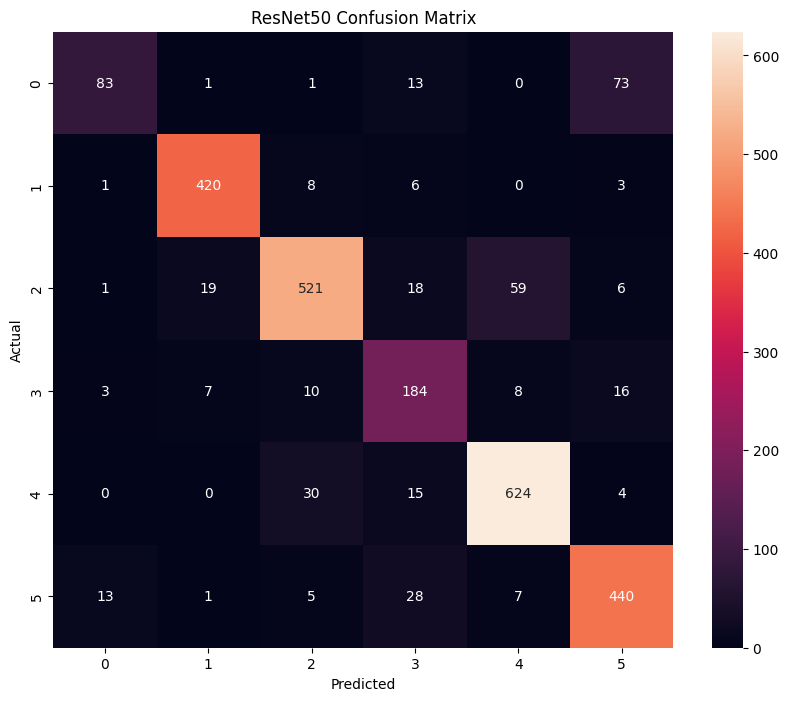

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "ResNet50 Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [37]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

torch.save(
    model.state_dict(),
    MODEL_DIR / "resnet50.pth"
)

print("Model Saved")

Model Saved
